<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/copy_of_omds_modc_week3_banerjee_jayeeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [ ]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42) #printing random sample of 10 rows

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
204,87930,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,...,24.64,96.05,677.9,0.14260,0.2378,0.2671,0.10150,0.3014,0.08750,B
70,859575,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,0.1582,...,26.58,165.90,1866.0,0.11930,0.2336,0.2687,0.17890,0.2551,0.06589,M
131,8670,15.46,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,0.1931,...,26.00,124.90,1156.0,0.15460,0.2394,0.3791,0.15140,0.2837,0.08019,M
431,907915,12.40,17.68,81.47,467.8,0.10540,0.13160,0.07741,0.02799,0.1811,...,22.91,89.61,515.8,0.14500,0.2629,0.2403,0.07370,0.2556,0.09359,B
540,921385,11.54,14.44,74.65,402.9,0.09984,0.11200,0.06737,0.02594,0.1818,...,19.68,78.78,457.8,0.13450,0.2118,0.1797,0.06918,0.2329,0.08134,B
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.8681,0.9387,0.26500,0.4087,0.12400,M
369,9012000,22.01,21.90,147.20,1482.0,0.10630,0.19540,0.24480,0.15010,0.1824,...,25.80,195.00,2227.0,0.12940,0.3885,0.4756,0.24320,0.2741,0.08574,M
29,853201,17.57,15.05,115.00,955.1,0.09847,0.11570,0.09875,0.07953,0.1739,...,19.52,134.90,1227.0,0.12550,0.2812,0.2489,0.14560,0.2756,0.07919,M
81,8611161,13.34,15.86,86.49,520.0,0.10780,0.15350,0.11690,0.06987,0.1942,...,23.19,96.66,614.9,0.15360,0.4791,0.4858,0.17080,0.3527,0.10160,B
477,911673,13.90,16.62,88.97,599.4,0.06828,0.05319,0.02224,0.01339,0.1813,...,21.80,101.20,718.9,0.09384,0.2006,0.1384,0.06222,0.2679,0.07698,B


In [ ]:
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
#Target and Features
X= df_BreastCancer.drop(["Diagnosis","ID"], axis=1)
y= df_BreastCancer["Diagnosis"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#-------------------------------------------------------
# Train-Test Split
#-------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

#-------------------------------------------------------
# 5-Fold Cross Validation Setup
#-------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

#=======================================================
# 1. FORWARD SELECTION (CV-based)
#=======================================================

def forward_selection_cv(X, y):
    remaining_features = list(X.columns)
    selected_features = []
    best_score = np.inf  # RMSE (lower is better)

    while len(remaining_features) > 0:
        scores = []

        for feature in remaining_features:
            features = selected_features + [feature]

            model = LinearRegression()

            cv_scores = cross_val_score(
                model,
                X[features],
                y,
                cv=cv,
                scoring='neg_root_mean_squared_error'
            )

            rmse = -cv_scores.mean()
            scores.append((feature, rmse))

        scores.sort(key=lambda x: x[1])
        best_feature, best_rmse = scores[0]

        if best_rmse < best_score:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            best_score = best_rmse
        else:
            break

    return selected_features, best_score


forward_features, forward_rmse = forward_selection_cv(X_train, y_train)

print("\nForward Selection Results")
print("-------------------------")
print("Selected Features:", forward_features)
print("Best CV RMSE:", forward_rmse)

# Fit final forward model
model_forward = LinearRegression()
model_forward.fit(X_train[forward_features], y_train)
y_pred_forward = model_forward.predict(X_test[forward_features])

# Evaluation
forward_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_forward))
forward_r2_test = r2_score(y_test, y_pred_forward)

print("\nForward Selection Test Results")
print("RMSE:", forward_rmse_test)
print("R²:", forward_r2_test)


#=======================================================
# 2. BACKWARD ELIMINATION (CV-based)
#=======================================================

def backward_elimination_cv(X, y):
    selected_features = list(X.columns)
    best_score = np.inf

    while len(selected_features) > 1:
        scores = []

        for feature in selected_features:
            features = [f for f in selected_features if f != feature]

            model = LinearRegression()

            cv_scores = cross_val_score(
                model,
                X[features],
                y,
                cv=cv,
                scoring='neg_root_mean_squared_error'
            )

            rmse = -cv_scores.mean()
            scores.append((feature, rmse))

        scores.sort(key=lambda x: x[1])
        worst_feature_removed, best_rmse = scores[0]

        if best_rmse < best_score:
            selected_features.remove(worst_feature_removed)
            best_score = best_rmse
        else:
            break

    return selected_features, best_score


backward_features, backward_rmse = backward_elimination_cv(X_train, y_train)

print("\nBackward Elimination Results")
print("----------------------------")
print("Selected Features:", backward_features)
print("Best CV RMSE:", backward_rmse)

# Fit final backward model
model_backward = LinearRegression()
model_backward.fit(X_train[backward_features], y_train)
y_pred_backward = model_backward.predict(X_test[backward_features])

# Evaluation
backward_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_backward))
backward_r2_test = r2_score(y_test, y_pred_backward)

print("\nBackward Selection Test Results")
print("RMSE:", backward_rmse_test)
print("R²:", backward_r2_test)


Forward Selection Results
-------------------------
Selected Features: ['concave_points3', 'radius3', 'texture3', 'smoothness1', 'area3', 'smoothness2', 'perimeter1', 'area1', 'symmetry1', 'compactness1', 'fractal_dimension3', 'radius1', 'concave_points1']
Best CV RMSE: 0.23919942982957906

Forward Selection Test Results
RMSE: 0.24806981636133185
R²: 0.7361837479324101

Backward Elimination Results
----------------------------
Selected Features: ['texture1', 'compactness1', 'concavity1', 'symmetry1', 'radius2', 'texture2', 'perimeter2', 'concavity2', 'concave_points2', 'radius3', 'area3', 'smoothness3', 'concavity3', 'fractal_dimension3']
Best CV RMSE: 0.23490987846669314

Backward Selection Test Results
RMSE: 0.25439359979501563
R²: 0.7225619281221771


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

#-------------------------------------------------------
# 5-Fold Cross Validation Setup
#-------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

#-------------------------------------------------------
# Backward Selection using CV RMSE
#-------------------------------------------------------

def backward_selection_cv(X, y):
    features = list(X.columns)
    best_score = np.inf  # RMSE (lower is better)

    while len(features) > 1:
        scores = []

        for feature in features:
            reduced_features = [f for f in features if f != feature]

            model = LinearRegression()

            cv_scores = cross_val_score(
                model,
                X[reduced_features],
                y,
                cv=cv,
                scoring='neg_root_mean_squared_error'
            )

            rmse = -cv_scores.mean()
            scores.append((feature, rmse))

        # Sort by best performance after removing a feature
        scores.sort(key=lambda x: x[1])
        worst_feature, best_rmse = scores[0]

        # Stop if removing improves model
        if best_rmse < best_score:
            features.remove(worst_feature)
            best_score = best_rmse
        else:
            break

    return features, best_score

#-------------------------------------------------------
# Run Backward Selection
#-------------------------------------------------------

selected_features_back, backward_cv_rmse = backward_selection_cv(X_train, y_train)

print("\nBackward Selection Results (CV-based)")
print("--------------------------------------")
print("Selected Features:", selected_features_back)
print("Best CV RMSE:", backward_cv_rmse)

#-------------------------------------------------------
# Final Model Training
#-------------------------------------------------------

model_backward = LinearRegression()
model_backward.fit(X_train[selected_features_back], y_train)

y_pred_backward = model_backward.predict(X_test[selected_features_back])

#-------------------------------------------------------
# Test Evaluation
#-------------------------------------------------------

backward_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_backward))
backward_r2_test = r2_score(y_test, y_pred_backward)

print("\nBackward Selection Test Results")
print("-------------------------------")
print("RMSE:", backward_rmse_test)
print("R²:", backward_r2_test)


Backward Selection Results (CV-based)
--------------------------------------
Selected Features: ['texture1', 'compactness1', 'concavity1', 'symmetry1', 'radius2', 'texture2', 'perimeter2', 'concavity2', 'concave_points2', 'radius3', 'area3', 'smoothness3', 'concavity3', 'fractal_dimension3']
Best CV RMSE: 0.23490987846669314

Backward Selection Test Results
-------------------------------
RMSE: 0.25439359979501563
R²: 0.7225619281221771



PCR Results (CV-based)
----------------------
Best number of components: 15
Best CV RMSE: 0.25125231720584995

PCR Test Results
----------------
RMSE: 0.2630454782340336
R²: 0.7033697913852146


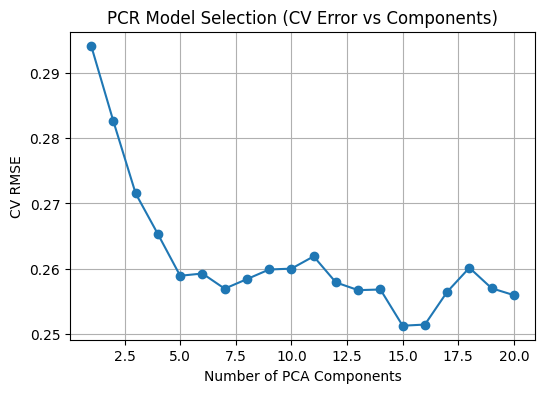

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

#-------------------------------------------------------
# Train-Test Split Scaling
#-------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#-------------------------------------------------------
# 5-Fold Cross Validation Setup
#-------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

#-------------------------------------------------------
# PCR: Tune number of PCA components using CV
#-------------------------------------------------------

max_components = min(X_train.shape[1], 20)  # limit for speed

cv_rmse = []

for k in range(1, max_components + 1):

    pca = PCA(n_components=k)

    X_train_pca = pca.fit_transform(X_train_scaled)

    model = LinearRegression()

    scores = cross_val_score(
        model,
        X_train_pca,
        y_train,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    )

    rmse = -scores.mean()
    cv_rmse.append(rmse)

# Best number of components
best_k = np.argmin(cv_rmse) + 1
best_rmse = min(cv_rmse)

print("\nPCR Results (CV-based)")
print("----------------------")
print("Best number of components:", best_k)
print("Best CV RMSE:", best_rmse)

#-------------------------------------------------------
# Fit final PCR model
#-------------------------------------------------------

pca = PCA(n_components=best_k)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model_pcr = LinearRegression()
model_pcr.fit(X_train_pca, y_train)

y_pred_pcr = model_pcr.predict(X_test_pca)

#-------------------------------------------------------
# Test evaluation
#-------------------------------------------------------

pcr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pcr))
pcr_r2 = r2_score(y_test, y_pred_pcr)

print("\nPCR Test Results")
print("----------------")
print("RMSE:", pcr_rmse)
print("R²:", pcr_r2)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cv_rmse)+1), cv_rmse, marker='o')
plt.xlabel("Number of PCA Components")
plt.ylabel("CV RMSE")
plt.title("PCR Model Selection (CV Error vs Components)")
plt.grid(True)
plt.show()


PLSR Results (CV-based)
-----------------------
Best number of components: 7
Best CV RMSE: 0.2503852398291866

PLSR Test Results
----------------
RMSE: 0.25449762032350765
R²: 0.7223349950931944


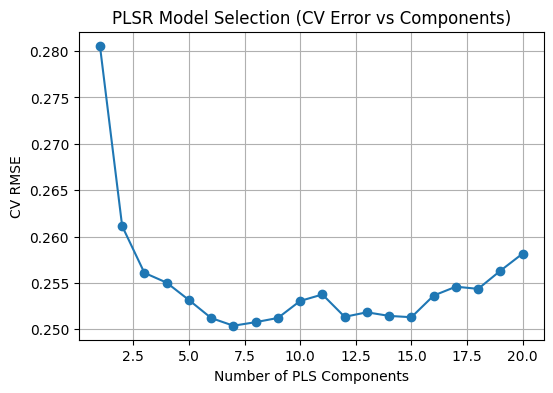

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

#-------------------------------------------------------
# Scaling (important for PLSR)
#-------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#-------------------------------------------------------
# 5-Fold Cross Validation Setup
#-------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

#-------------------------------------------------------
# Tune number of PLS components using CV
#-------------------------------------------------------

max_components = min(X_train.shape[1], 20)

cv_rmse = []

for k in range(1, max_components + 1):

    model = PLSRegression(n_components=k)

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    )

    rmse = -scores.mean()
    cv_rmse.append(rmse)

# Best number of components
best_k = np.argmin(cv_rmse) + 1
best_rmse = min(cv_rmse)

print("\nPLSR Results (CV-based)")
print("-----------------------")
print("Best number of components:", best_k)
print("Best CV RMSE:", best_rmse)

#-------------------------------------------------------
# Train final PLSR model
#-------------------------------------------------------

model_pls = PLSRegression(n_components=best_k)
model_pls.fit(X_train_scaled, y_train)

y_pred_pls = model_pls.predict(X_test_scaled)

#-------------------------------------------------------
# Evaluation
#-------------------------------------------------------

pls_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pls))
pls_r2 = r2_score(y_test, y_pred_pls)

print("\nPLSR Test Results")
print("----------------")
print("RMSE:", pls_rmse)
print("R²:", pls_r2)

#Curve plot
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cv_rmse)+1), cv_rmse, marker='o')
plt.xlabel("Number of PLS Components")
plt.ylabel("CV RMSE")
plt.title("PLSR Model Selection (CV Error vs Components)")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#-------------------------------------------------------
# Model dictionary (clean + consistent)
#-------------------------------------------------------

models = {
    "Forward Selection": (
        model_forward,
        X_test[forward_features]   # updated name
    ),
    "Backward Selection": (
        model_backward,
        X_test[backward_features]  # updated name
    ),
    "PCR": (
        model_pcr,
        X_test_pca
    ),
    "PLSR": (
        model_pls,
        X_test_scaled
    )
}

#-------------------------------------------------------
# Evaluation loop
#-------------------------------------------------------

print("\nModel Performance Comparison")
print("----------------------------")

for name, (model, X_data) in models.items():

    pred = model.predict(X_data)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(name)
    print("R²   :", r2)
    print("RMSE :", rmse)
    print()

#-------------------------------------------------------
# Separate PLSR (since it's already stored as prediction model)
#-------------------------------------------------------

pls_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pls))
pls_r2 = r2_score(y_test, y_pred_pls)

print("PLSR (direct)")
print("R²   :", pls_r2)
print("RMSE :", pls_rmse)


Model Performance Comparison
----------------------------
Forward Selection
R²   : 0.7361837479324101
RMSE : 0.24806981636133185

Backward Selection
R²   : 0.7225619281221771
RMSE : 0.25439359979501563

PCR
R²   : 0.7033697913852146
RMSE : 0.2630454782340336

PLSR
R²   : 0.7223349950931944
RMSE : 0.25449762032350765

PLSR (direct)
R²   : 0.7223349950931944
RMSE : 0.25449762032350765


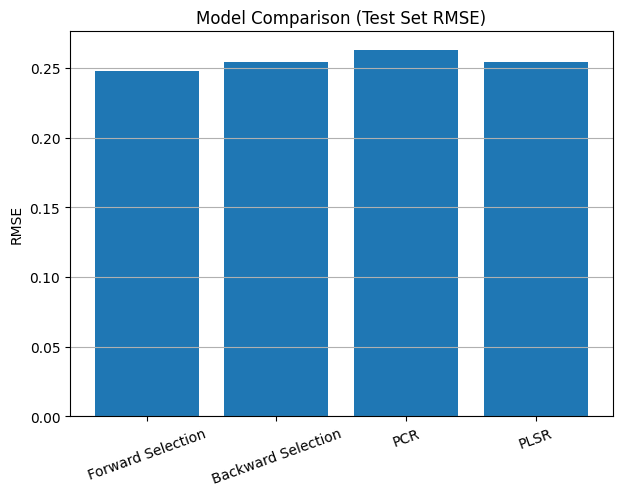

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

#-------------------------------------------------------
# Compute RMSEs (consistent + safe)
#-------------------------------------------------------

rmse_forward = np.sqrt(mean_squared_error(
    y_test, model_forward.predict(X_test[forward_features])
))

rmse_backward = np.sqrt(mean_squared_error(
    y_test, model_backward.predict(X_test[backward_features])
))

rmse_pcr = np.sqrt(mean_squared_error(
    y_test, model_pcr.predict(X_test_pca)
))

rmse_plsr = np.sqrt(mean_squared_error(
    y_test, y_pred_pls
))

#-------------------------------------------------------
# Model names (clean for reporting)
#-------------------------------------------------------

model_names = [
    "Forward Selection",
    "Backward Selection",
    "PCR",
    "PLSR"
]

rmse_values = [
    rmse_forward,
    rmse_backward,
    rmse_pcr,
    rmse_plsr
]

#-------------------------------------------------------
# Plot
#-------------------------------------------------------

plt.figure(figsize=(7,5))
plt.bar(model_names, rmse_values)

plt.ylabel("RMSE")
plt.title("Model Comparison (Test Set RMSE)")
plt.xticks(rotation=20)
plt.grid(axis='y')

plt.show()

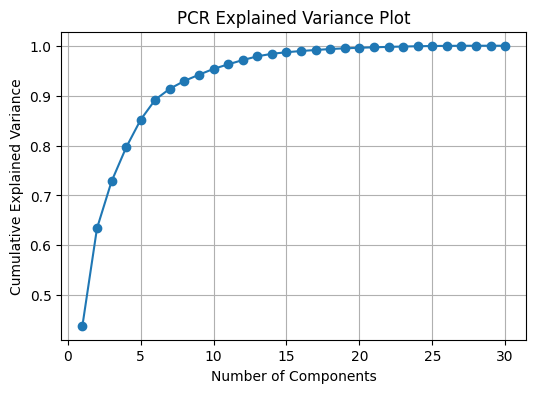

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Fit PCA on full feature space
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Cumulative explained variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Plot
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCR Explained Variance Plot")
plt.grid(True)

plt.show()

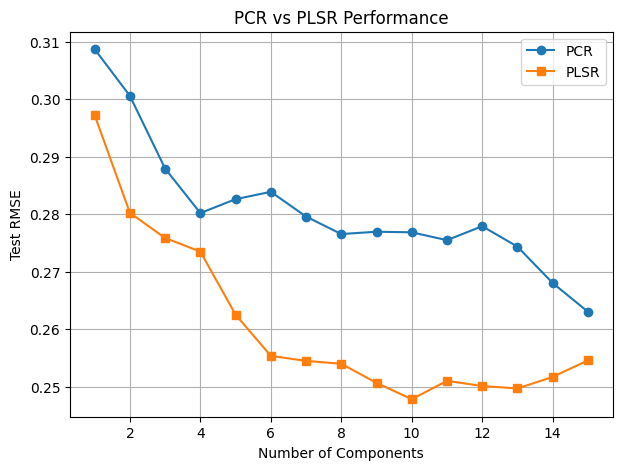

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

#-------------------------------------------------------
# PCR
#-------------------------------------------------------

rmse_pcr = []

for n in range(1, 16):

    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    model = LinearRegression()
    model.fit(X_train_pca, y_train)

    y_pred = model.predict(X_test_pca)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    rmse_pcr.append(rmse)

#-------------------------------------------------------
# PLSR
#-------------------------------------------------------

rmse_plsr = []

for n in range(1, 16):

    pls = PLSRegression(n_components=n)
    pls.fit(X_train_scaled, y_train)

    y_pred = pls.predict(X_test_scaled).ravel()
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    rmse_plsr.append(rmse)

#-------------------------------------------------------
# Plot
#-------------------------------------------------------

components = range(1, 16)

plt.figure(figsize=(7,5))
plt.plot(components, rmse_pcr, marker='o')
plt.plot(components, rmse_plsr, marker='s')

plt.xlabel("Number of Components")
plt.ylabel("Test RMSE")
plt.title("PCR vs PLSR Performance")
plt.legend(["PCR", "PLSR"])
plt.grid(True)

plt.show()